# COMP 6940: Big Data and Data Visualization

### Project: Airline Delay Analysis and Performance Optimization  
#### Dataset: Carrier On-Time Performance Dataset  

## **Notebook:** 03 - Delay Cause Attribution

**Objective:** 

This notebook builds on the exploratory analysis conducted in Notebook 2 by investigating the underlying causes of flight delays. While previous analysis focused on identifying when and where delays occur, this notebook aims to explain why delays happen by decomposing total delay into its contributing components.

The analysis focuses on key delay categories:
- Carrier delays (operational inefficiencies)
- Weather delays (external environmental factors)
- NAS delays (air traffic control and system congestion)
- Security delays (screening and safety-related disruptions)
- Late aircraft delays (delay propagation from previous flights)

By attributing delays to these causes, this notebook provides a more detailed understanding of the primary drivers of delays, helping to distinguish between operational inefficiencies and uncontrollable external factors.

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

CAUSES = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]
CAUSE_LABELS = ["Carrier", "Weather", "NAS", "Security", "Late aircraft"]

In [3]:
df = pd.read_csv("cleaned_flight_data.csv", low_memory=False)
df["FlightDate"] = pd.to_datetime(df["FlightDate"], errors="coerce")

for c in CAUSES:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

if "TotalCauseDelay" not in df.columns:
    df["TotalCauseDelay"] = df[CAUSES].sum(axis=1)

if "IsArrivalDelayed" not in df.columns:
    df["IsArrivalDelayed"] = pd.to_numeric(df["ArrDelay"], errors="coerce").fillna(0) > 0
else:
    df["IsArrivalDelayed"] = df["IsArrivalDelayed"].astype(bool)

if "Season" not in df.columns:
    m = df["FlightDate"].dt.month
    df["Season"] = np.select(
        [m.isin([12, 1, 2]), m.isin([3, 4, 5]), m.isin([6, 7, 8])],
        ["Winter", "Spring", "Summer"],
        default="Autumn",
    )

oper = df[df["Cancelled"] == 0].copy()
oper["ArrDelay"] = pd.to_numeric(oper["ArrDelay"], errors="coerce")

## A) Overall Attribution of Delay Causes (Total Minutes and Percentage Share)

This section quantifies the **overall contribution of each delay cause** by examining both the **total delay minutes** and the **percentage share of total delay**.

By combining absolute and relative measures, this analysis provides a comprehensive view of which delay causes dominate the system, allowing us to distinguish between **high-frequency contributors** and **high-impact contributors**.

In [4]:
totals = oper[CAUSES].sum()
grand = totals.sum()
pct = (totals / grand * 100).round(2)
overall = pd.DataFrame({"total_minutes": totals, "pct_of_all_cause_delay": pct})
overall

,total_minutes,pct_of_all_cause_delay
CarrierDelay,3746825.0,29.45
WeatherDelay,652085.0,5.13
NASDelay,3413414.0,26.83
SecurityDelay,18825.0,0.15
LateAircraftDelay,4891681.0,38.45


The table above presents the **total delay minutes** attributed to each cause, along with the **percentage contribution to overall delay**. This allows for direct comparison of the relative importance of each delay type.

---

To complement the tabular summary, the following visualization presents the same information graphically, making it easier to compare the magnitude of delay contributions across causes.

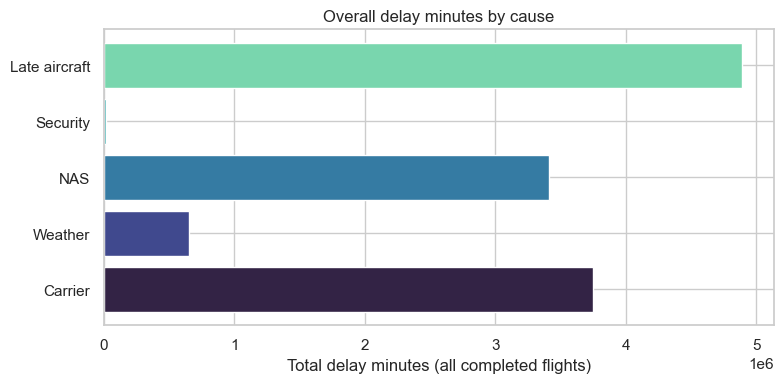

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(CAUSE_LABELS, totals.values, color=sns.color_palette("mako", len(CAUSES)))
ax.set_xlabel("Total delay minutes (all completed flights)")
ax.set_title("Overall delay minutes by cause")
plt.tight_layout()
plt.show()

**Insight:**

The results show that **Late Aircraft Delay is the largest contributor**, accounting for approximately **38.45% of total delay minutes**, followed by **Carrier Delay (29.45%)** and **NAS Delay (26.83%)**.

- **Late Aircraft Delay** highlights strong delay propagation effects, where delays from earlier flights cascade into subsequent operations.
- **Carrier Delay** reflects internal airline inefficiencies such as crew scheduling, maintenance, and boarding delays.
- **NAS Delay** indicates congestion within the air traffic control system.

In contrast:
- **Weather Delay contributes only ~5.13%**, suggesting that external environmental factors play a smaller role than expected.
- **Security Delay is negligible (~0.15%)**, indicating minimal impact on overall system performance.

Overall, the findings demonstrate that **over 90% of delays are driven by operational and systemic factors**, rather than uncontrollable external events. This strongly suggests that improvements in airline operations and scheduling would yield the most significant reductions in delays.

---

## B) Delay Cause Attribution by Airline (Summary Table)

This section provides a detailed breakdown of delay behavior across airlines by summarizing both the **average delay per flight** and the **total delay minutes** for each delay cause.

In addition, the percentage contribution of each delay type is computed, allowing for comparison of how delays are distributed across carriers. This enables us to distinguish between airlines with **high overall delay volume** and those with **more severe or concentrated delay patterns**.


The table below summarizes delay metrics for each airline, including:
- Average delay per flight by cause  
- Total delay minutes by cause  
- Percentage contribution of each delay type  
- Total number of flights  

This provides a comprehensive view of both the **scale** and **structure** of delays across airlines.

In [11]:
g_air = oper.groupby("Reporting_Airline", observed=True)
sum_c = g_air[CAUSES].sum()
mean_c = g_air[CAUSES].mean()
row_sum = sum_c.sum(axis=1).replace(0, np.nan)
pct_air = sum_c.div(row_sum, axis=0) * 100

airline_delay_summary = mean_c.add_prefix("avg_")
for c in CAUSES:
    airline_delay_summary[f"total_{c}"] = sum_c[c]
for c in CAUSES:
    airline_delay_summary[f"pct_{c}"] = pct_air[c].round(2)
airline_delay_summary["flights"] = g_air.size()
airline_delay_summary = airline_delay_summary.reset_index()
airline_delay_summary.head(10)

,Reporting_Airline,avg_CarrierDelay,avg_WeatherDelay,avg_NASDelay,avg_SecurityDelay,avg_LateAircraftDelay,total_CarrierDelay,total_WeatherDelay,total_NASDelay,total_SecurityDelay,total_LateAircraftDelay,pct_CarrierDelay,pct_WeatherDelay,pct_NASDelay,pct_SecurityDelay,pct_LateAircraftDelay,flights
0,9E,3.586770,0.594549,3.117730,0.011277,4.020727,68701.0,11388.0,59717.0,216.0,77013.0,31.65,5.25,27.51,0.10,35.48,19154
1,AA,1.965606,0.368859,1.733056,0.009161,2.222065,452736.0,84959.0,399173.0,2110.0,511806.0,31.21,5.86,27.51,0.15,35.28,230329
2,AS,1.647834,0.115917,1.302128,0.029536,2.006520,80617.0,5671.0,63704.0,1445.0,98165.0,32.30,2.27,25.52,0.58,39.33,48923
3,B6,4.421219,0.447520,4.585505,0.039937,6.351119,163731.0,16573.0,169815.0,1479.0,235201.0,27.90,2.82,28.94,0.25,40.08,37033
4,CO,0.789940,0.127940,1.543011,0.011394,0.883320,70856.0,11476.0,138405.0,1022.0,79232.0,23.54,3.81,45.98,0.34,26.32,89698
5,DH,2.029666,0.489631,3.350374,0.001008,4.861319,14094.0,3400.0,23265.0,7.0,33757.0,18.91,4.56,31.22,0.01,45.30,6944
6,DL,1.491169,0.254138,1.420159,0.002691,1.373757,389037.0,66303.0,370511.0,702.0,358405.0,32.83,5.60,31.27,0.06,30.25,260894
7,EA,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,9068
8,EV,5.306233,0.895279,3.668425,0.007410,5.139882,348004.0,58716.0,240590.0,486.0,337094.0,35.33,5.96,24.43,0.05,34.23,65584
9,F9,3.165009,0.246420,4.072099,0.000494,5.312099,44864.0,3493.0,57722.0,7.0,75299.0,24.73,1.93,31.82,0.00,41.51,14175


**Insight:**

The airline-level summary reveals several important patterns in delay behavior:

- Airlines such as **EV and B6 exhibit the highest average delay values**, particularly for **Late Aircraft Delay and NAS Delay**, indicating more severe delays per flight.
- In contrast, major carriers like **AA and DL show lower average delays**, despite having high total delay minutes, suggesting that their delays are more distributed across a larger number of flights.

Across all airlines, **Late Aircraft Delay and Carrier Delay remain the dominant contributors**, reinforcing that delay propagation and operational inefficiencies are the primary drivers of delays.

Additionally:
- **Weather delays are consistently low across airlines**, indicating limited impact from external environmental factors.
- **Security delays are negligible**, contributing almost nothing to total delay.

A key distinction emerges between:
- **High-volume airlines (large total delays but moderate averages)**  
- **Lower-volume airlines with higher average delays per flight**

This suggests that while some airlines experience delays due to scale, others may be more affected by **operational inefficiencies and weaker delay recovery mechanisms**.

Overall, the results confirm that delays are driven more by **internal airline operations and cascading effects** than by external disruptions.

---

## C) Delay Attribution by Origin Airport (Averages, Delay Rate, Dominant Cause)

This section analyzes delay behavior at the **origin airport level**, summarizing both the **average delay per flight** and the **total delay minutes** for each delay cause.

In addition, two key metrics are included:
- **Delay rate**: the proportion of flights arriving late from each airport  
- **Dominant cause**: the delay category contributing the most total delay at that airport  

This allows us to identify whether delays at specific airports are driven by **operational inefficiencies, congestion, or localized factors**, and to compare both the **severity and frequency** of delays across locations.

The table below summarizes delay characteristics for each origin airport, including:
- Average delay per flight by cause  
- Total delay minutes by cause  
- Delay rate (proportion of delayed flights)  
- Dominant delay cause  
- Total number of flights  

This provides a comprehensive view of how delay patterns vary across different locations.

In [12]:
g_ap = oper.groupby("Origin", observed=True)
sum_ap = g_ap[CAUSES].sum()
mean_ap = g_ap[CAUSES].mean()
delay_rate = g_ap["IsArrivalDelayed"].mean()
dominant = sum_ap.idxmax(axis=1)

airport_delay_summary = mean_ap.add_prefix("avg_")
for c in CAUSES:
    airport_delay_summary[f"total_{c}"] = sum_ap[c]
airport_delay_summary["delay_rate"] = delay_rate
airport_delay_summary["dominant_cause"] = dominant.values
airport_delay_summary["flights"] = g_ap.size()
airport_delay_summary = airport_delay_summary.reset_index()
airport_delay_summary.head(10)

,Origin,avg_CarrierDelay,avg_WeatherDelay,avg_NASDelay,avg_SecurityDelay,avg_LateAircraftDelay,total_CarrierDelay,total_WeatherDelay,total_NASDelay,total_SecurityDelay,total_LateAircraftDelay,delay_rate,dominant_cause,flights
0,ABE,1.795739,0.127820,1.834586,0.000000,1.770677,2866.0,204.0,2928.0,0.0,2826.0,0.402256,NASDelay,1596
1,ABI,3.861472,0.733766,1.251082,0.000000,2.595238,1784.0,339.0,578.0,0.0,1199.0,0.309524,CarrierDelay,462
2,ABQ,0.961592,0.167826,0.760089,0.004824,2.213471,10365.0,1809.0,8193.0,52.0,23859.0,0.423138,LateAircraftDelay,10779
3,ABR,22.987500,0.912500,0.825000,0.112500,4.325000,1839.0,73.0,66.0,9.0,346.0,0.275000,CarrierDelay,80
4,ABY,5.978022,0.593407,4.335165,0.000000,5.016484,1088.0,108.0,789.0,0.0,913.0,0.489011,CarrierDelay,182
5,ACK,0.726027,0.000000,21.465753,0.123288,8.986301,53.0,0.0,1567.0,9.0,656.0,0.520548,NASDelay,73
6,ACT,2.498462,0.372308,1.178462,0.000000,1.880000,812.0,121.0,383.0,0.0,611.0,0.289231,CarrierDelay,325
7,ACV,3.047710,0.185115,4.419847,0.000000,8.288168,1597.0,97.0,2316.0,0.0,4343.0,0.391221,LateAircraftDelay,524
8,ACY,3.844444,0.092593,3.451852,0.000000,4.051852,1038.0,25.0,932.0,0.0,1094.0,0.351852,LateAircraftDelay,270
9,ADK,1.045455,0.000000,0.000000,1.272727,2.181818,23.0,0.0,0.0,28.0,48.0,0.409091,LateAircraftDelay,22


**Insight:**

The airport-level summary highlights substantial variation in both the **severity and frequency of delays** across origin locations:

- Certain airports (e.g., ABR, ACK) exhibit **very high average delay values**, particularly for **NAS and Late Aircraft delays**, indicating more severe disruptions per flight.
- In contrast, other airports show **lower average delays but higher total delay minutes**, suggesting that delay volume is driven by traffic scale rather than severity.

The inclusion of **delay rate** provides additional insight:
- Airports with higher delay rates experience **more frequent disruptions**, even if the average delay per flight is moderate.
- This helps distinguish between airports with **consistent minor delays** and those with **less frequent but more severe delays**.

The **dominant cause** column reveals that:
- **Late Aircraft Delay and NAS Delay frequently appear as the primary contributors**, indicating strong roles for delay propagation and airspace congestion.
- Weather and Security delays are rarely dominant, reinforcing their relatively limited impact.

Thus, the findings suggest that delays at the airport level are influenced by a combination of:
- **Operational factors (carrier, aircraft turnaround)**  
- **System congestion (NAS delays)**  
- **Local traffic conditions**

This highlights the importance of targeting **high-delay airports with both high delay rates and high average delays**, as these locations are likely key drivers of network-wide disruption.

---

## D) Temporal Analysis of Delay Causes (Monthly and Seasonal)

This section examines how delay causes vary over time by summarizing both **monthly** and **seasonal** patterns. For each time period, both the **total delay minutes** and the **average delay per flight** are calculated across all delay categories.

By combining monthly and seasonal perspectives, this analysis allows us to identify **short-term fluctuations** as well as **broader temporal trends**, providing insight into how demand cycles and operational pressures influence delay behavior.

The table below presents delay summaries grouped by **month and season**, including:
- Total delay minutes by cause  
- Average delay per flight by cause  
- A time-grain indicator distinguishing monthly and seasonal aggregation  

This structure enables comparison of both fine-grained (monthly) and aggregated (seasonal) delay patterns.

In [13]:
by_month = oper.groupby("Month", observed=False)
by_season = oper.groupby("Season", observed=True)

def pack_time(gb, name):
    s = gb[CAUSES].sum().add_prefix("total_")
    m = gb[CAUSES].mean().add_prefix("avg_")
    out = pd.concat([s, m], axis=1)
    out.insert(0, "time_grain", name)
    return out.reset_index()

seasonal_delay_summary = pd.concat(
    [
        pack_time(by_month, "month").rename(columns={"Month": "period"}),
        pack_time(by_season, "season").rename(columns={"Season": "period"}),
    ],
    ignore_index=True,
)
seasonal_delay_summary.head(8)

,period,time_grain,total_CarrierDelay,total_WeatherDelay,total_NASDelay,total_SecurityDelay,total_LateAircraftDelay,avg_CarrierDelay,avg_WeatherDelay,avg_NASDelay,avg_SecurityDelay,avg_LateAircraftDelay
0,1,month,316121.0,70754.0,288040.0,1545.0,390854.0,1.921241,0.430011,1.750577,0.009390,2.375435
1,2,month,296594.0,59163.0,262894.0,1661.0,369627.0,1.958350,0.390641,1.735835,0.010967,2.440572
2,3,month,316035.0,41577.0,275069.0,1357.0,402761.0,1.849012,0.243253,1.609334,0.007939,2.356416
3,4,month,278439.0,46922.0,252849.0,977.0,360720.0,1.730746,0.291662,1.571682,0.006073,2.242196
4,5,month,279875.0,50593.0,281570.0,846.0,388850.0,1.699746,0.307263,1.710040,0.005138,2.361576
5,6,month,393010.0,78076.0,356280.0,1566.0,563800.0,2.402864,0.477357,2.178297,0.009575,3.447074
6,7,month,408306.0,77973.0,362898.0,1784.0,567787.0,2.416784,0.461526,2.148012,0.010560,3.360760
7,8,month,350063.0,62509.0,317350.0,3034.0,480301.0,2.067513,0.369185,1.874306,0.017919,2.836714


**Insight:**

The temporal breakdown reveals clear patterns in how delays evolve over time:

- At the **monthly level**, delay contributions tend to increase during **mid-year months (e.g., June–July)** and again toward **December**, indicating periods of heightened operational strain.
- **Late Aircraft Delay and Carrier Delay consistently remain the largest contributors across months**, suggesting that delay propagation and operational inefficiencies intensify during peak travel periods.
- **NAS Delay also increases during high-demand months**, reflecting congestion within the airspace system.

At the **seasonal level**:
- **Summer exhibits the highest total delays across most categories**, aligning with peak travel demand.
- **Winter shows moderate delay levels**, with slightly more variation potentially linked to weather conditions.
- **Spring and Autumn generally display lower delay levels**, indicating reduced system pressure.

Overall, the results demonstrate that delay behavior is strongly influenced by **temporal demand cycles**, with peak travel periods amplifying both the **frequency and severity of delays**, primarily through operational and congestion-related factors rather than external disruptions.

---

## E) Route-Level Snapshot (Routes with at Least 2,000 Flights)

This section summarizes delay behavior at the **route level**, where each route is defined as an origin–destination airport pair. To ensure that comparisons are based on sufficiently representative traffic, the analysis is restricted to routes with **at least 2,000 flights**.

For each qualifying route, the notebook reports the **average arrival delay** along with the **average contribution of each delay cause**. This helps identify heavily travelled routes that experience persistently poor performance and reveals whether route-level delays are driven more by **carrier effects, congestion, weather, or delay propagation**.

The table below presents the highest-delay high-volume routes, ranked by **average arrival delay**. Alongside the overall average arrival delay, the average contribution of each major delay cause is shown to highlight the dominant sources of disruption on each route.

In [14]:
if "Route" not in oper.columns:
    oper["Route"] = oper["Origin"].astype(str) + "-" + oper["Dest"].astype(str)

rc = oper.groupby("Route", observed=True).agg(
    flights=("Route", "size"),
    avg_arr_delay=("ArrDelay", "mean"),
    **{f"avg_{c}": (c, "mean") for c in CAUSES},
)
route_delay_summary = rc[rc["flights"] >= 2000].sort_values("avg_arr_delay", ascending=False)
route_delay_summary.head(15)

,flights,avg_arr_delay,avg_CarrierDelay,avg_WeatherDelay,avg_NASDelay,avg_SecurityDelay,avg_LateAircraftDelay
Route,,,,,,,
ATL-EWR,2116,14.940702,1.094991,0.336957,7.661153,0.000000,2.644140
ORD-EWR,2650,13.537704,1.259623,0.325660,5.064906,0.000000,2.798868
ORD-SFO,2207,13.458012,2.970095,0.872225,4.138650,0.005437,3.277753
ATL-ORD,2560,11.797964,1.675000,0.630859,3.582031,0.003125,2.409766
SAN-SFO,2053,11.679024,0.672674,0.104725,4.474915,0.000000,3.062835
SEA-SFO,2405,11.623696,1.282328,0.303119,3.940956,0.000000,1.861954
ORD-BOS,2446,11.550736,1.746934,0.352003,2.714227,0.000000,3.575634
ORD-DEN,2040,11.513977,1.983333,1.150000,1.534314,0.000000,3.048529
ORD-ATL,2648,11.242711,2.005665,0.308157,2.606873,0.000000,3.518505


**Insight:**

The route-level summary shows that some high-volume routes experience **substantially worse average arrival delays** than others, even after restricting attention to routes with large traffic volume.

Several patterns stand out:

- Routes such as **ATL–EWR, ORD–EWR, and ORD–SFO** appear among the highest-delay routes, indicating that delays are concentrated on important and heavily travelled corridors.
- For many of these routes, **NAS Delay and Late Aircraft Delay contribute strongly**, suggesting that both **airspace congestion** and **delay propagation** are major sources of poor route performance.
- **Carrier Delay** is also present across several routes, but the table suggests that route-level disruption is often amplified by network effects rather than airline operations alone.
- **Security Delay is negligible**, and **Weather Delay is generally smaller**, indicating that these are not the dominant explanations for the worst-performing major routes.

Overall, the findings suggest that the most delay-prone high-volume routes are typically those exposed to **busy hubs, congested airspace, and cascading delays from earlier flights**. These routes likely serve as important channels through which delays spread across the broader network.

---

## F) Visual Summaries of Delay Attribution

This section presents a series of visualizations that complement the tabular summaries developed earlier in the notebook. These charts are used to compare delay causes across **airlines, origin airports, months, seasons, and major hubs**.

Together, the visual summaries provide a clearer view of the **magnitude, composition, and temporal variation** of delay causes, helping to highlight patterns that may be less obvious in tabular form alone.

### F.1 Delay Cause Composition by Airline

The stacked bar chart below shows the **total delay minutes by cause** for the top 12 airlines by flight volume. This makes it possible to compare both the **overall amount of delay** and the **relative contribution of each cause** across major carriers.

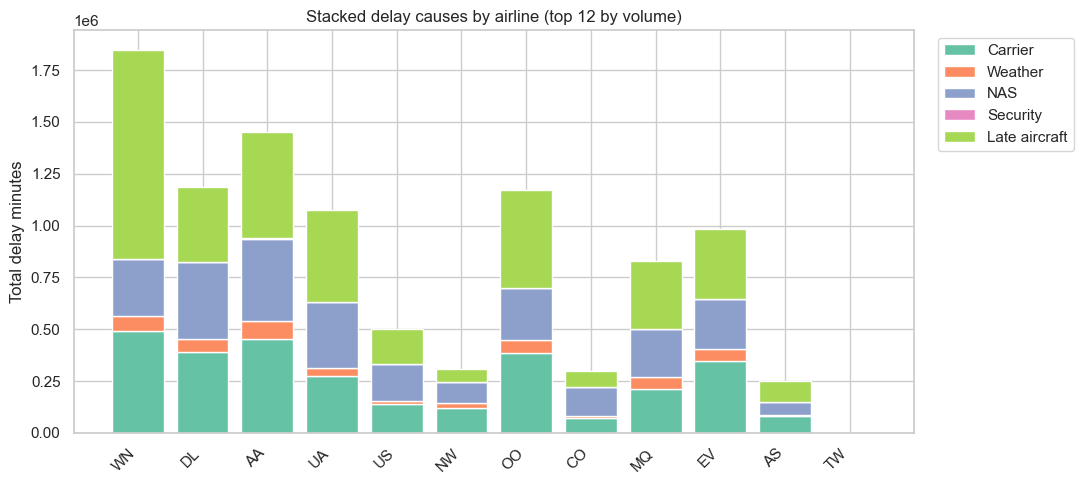

In [38]:
top_n = 12
air_order = airline_delay_summary.nlargest(top_n, "flights")["Reporting_Airline"]
sub = sum_c.loc[air_order]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(sub))
colors = sns.color_palette("Set2", len(CAUSES))
for i, c in enumerate(CAUSES):
    ax.bar(sub.index.astype(str), sub[c].values, bottom=bottom, label=CAUSE_LABELS[i], color=colors[i])
    bottom += sub[c].values
ax.set_ylabel("Total delay minutes")
ax.set_title("Stacked delay causes by airline (top 12 by volume)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Insight:**

The airline-level visualization shows that **Late Aircraft Delay, Carrier Delay, and NAS Delay dominate total delay minutes** across the largest carriers.

- Airlines with the highest total traffic, such as **WN, AA, and DL**, naturally accumulate larger total delays.
- However, the composition of delays is fairly consistent across airlines, with **Late Aircraft Delay frequently forming the largest share**.
- This indicates that **delay propagation is a system-wide issue**, not one restricted to a single carrier.
- **Weather and Security delays remain relatively minor**, reinforcing the conclusion that most delays are driven by operational and network effects.

Overall, the chart suggests that the largest opportunities for delay reduction lie in improving **aircraft turnaround efficiency, schedule recovery, and coordination across the network**.

---

### F.2 Delay Cause Composition by Origin Airport

The next stacked bar chart presents the **total delay minutes by cause** for the top 12 origin airports by flight volume. This helps identify whether major airports share similar delay structures or whether some locations are more affected by specific causes.

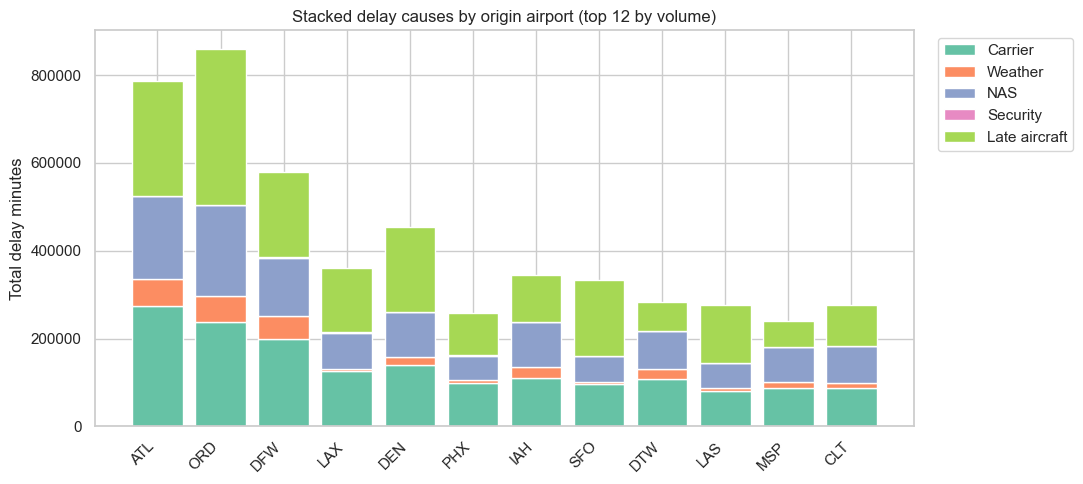

In [40]:
ap_order = airport_delay_summary.nlargest(top_n, "flights")["Origin"]
sub_ap = sum_ap.loc[ap_order]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(sub_ap))
colors = sns.color_palette("Set2", len(CAUSES))
for i, c in enumerate(CAUSES):
    ax.bar(sub_ap.index.astype(str), sub_ap[c].values, bottom=bottom, label=CAUSE_LABELS[i], color=colors[i])
    bottom += sub_ap[c].values
ax.set_ylabel("Total delay minutes")
ax.set_title("Stacked delay causes by origin airport (top 12 by volume)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Insight:**

The airport-level chart shows that large hubs such as **ATL, ORD, and DFW** account for the greatest total delay minutes, which is consistent with their high traffic volume and operational complexity.

Key patterns include:

- **Late Aircraft Delay and Carrier Delay remain major contributors**, showing that airport-level delays are strongly linked to operational inefficiencies and cascading disruptions.
- **NAS Delay is also substantial at major hubs**, reflecting congestion in busy airspace and airport systems.
- The similarity in composition across airports suggests that many large hubs are affected by the same underlying system pressures.
- Weather contributes less overall, though it appears somewhat more variable across airports than security-related delays.

Overall, the results indicate that major hub airports are central points in the generation and transmission of delays throughout the network.

---

### F.3 Monthly Variation in Delay Causes

The heatmap below displays **total delay minutes by month and cause**, allowing us to identify seasonal peaks and compare how different causes evolve across the year.

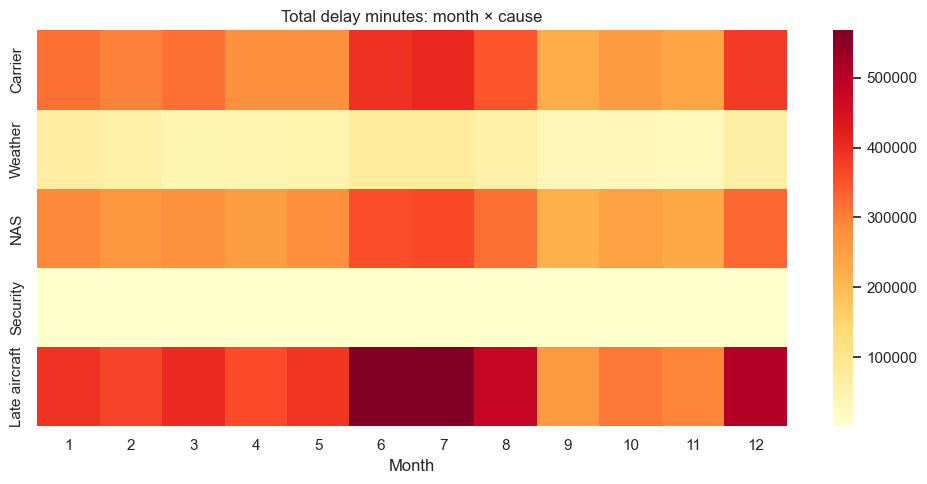

In [26]:
m_sum = oper.groupby("Month", observed=False)[CAUSES].sum()
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(m_sum.T, cmap="YlOrRd", ax=ax, yticklabels=CAUSE_LABELS)
ax.set_title("Total delay minutes: month × cause")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

**Insight:**

The monthly heatmap reveals clear temporal structure in delay behavior:

- **Late Aircraft Delay is consistently the largest contributor across months**, with particularly strong intensity during **June, July, and December**.
- **Carrier Delay and NAS Delay follow similar monthly patterns**, suggesting that operational strain and congestion increase together during busy periods.
- **Weather Delay remains comparatively smaller**, though it is present throughout the year.
- **Security Delay is minimal in every month**, confirming its negligible role in total delay generation.

These patterns indicate that **peak travel periods amplify existing operational weaknesses**, especially those related to propagation and congestion. The monthly view therefore reinforces the conclusion that delays are strongly shaped by demand cycles.

---

### F.4 Seasonal Variation in Delay Causes

To complement the monthly analysis, the following heatmap aggregates delay minutes by **season and cause**. This provides a broader view of how delay patterns change across Winter, Spring, Summer, and Autumn.

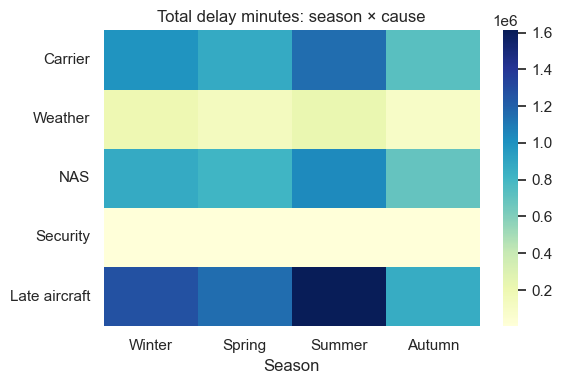

In [27]:
s_sum = oper.groupby("Season", observed=True)[CAUSES].sum()
s_sum = s_sum.reindex(["Winter", "Spring", "Summer", "Autumn"], fill_value=0)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(s_sum.T, cmap="YlGnBu", ax=ax, yticklabels=CAUSE_LABELS)
ax.set_title("Total delay minutes: season × cause")
plt.tight_layout()
plt.show()

**Insights**

The seasonal heatmap shows that **Summer records the highest total delay minutes across nearly all major causes**, especially for **Late Aircraft Delay, Carrier Delay, and NAS Delay**.

- This is consistent with increased travel demand and tighter operational capacity during peak months.
- **Winter also shows substantial delays**, though generally below Summer levels.
- **Spring and Autumn exhibit lower totals**, suggesting comparatively reduced system pressure during those periods.
- As in earlier sections, **Security Delay remains negligible**, while Weather Delay contributes modestly relative to the larger operational causes.

Overall, the seasonal analysis confirms that delay severity is strongly influenced by **traffic intensity and congestion**, with Summer standing out as the most disruptive period.

---

### F.5 Top Origin Airports by Individual Delay Cause

The final set of plots identifies the leading origin airports for each delay type separately. By isolating each cause, this analysis helps show which airports are most strongly associated with **Carrier, Weather, NAS, Security, and Late Aircraft delays**.

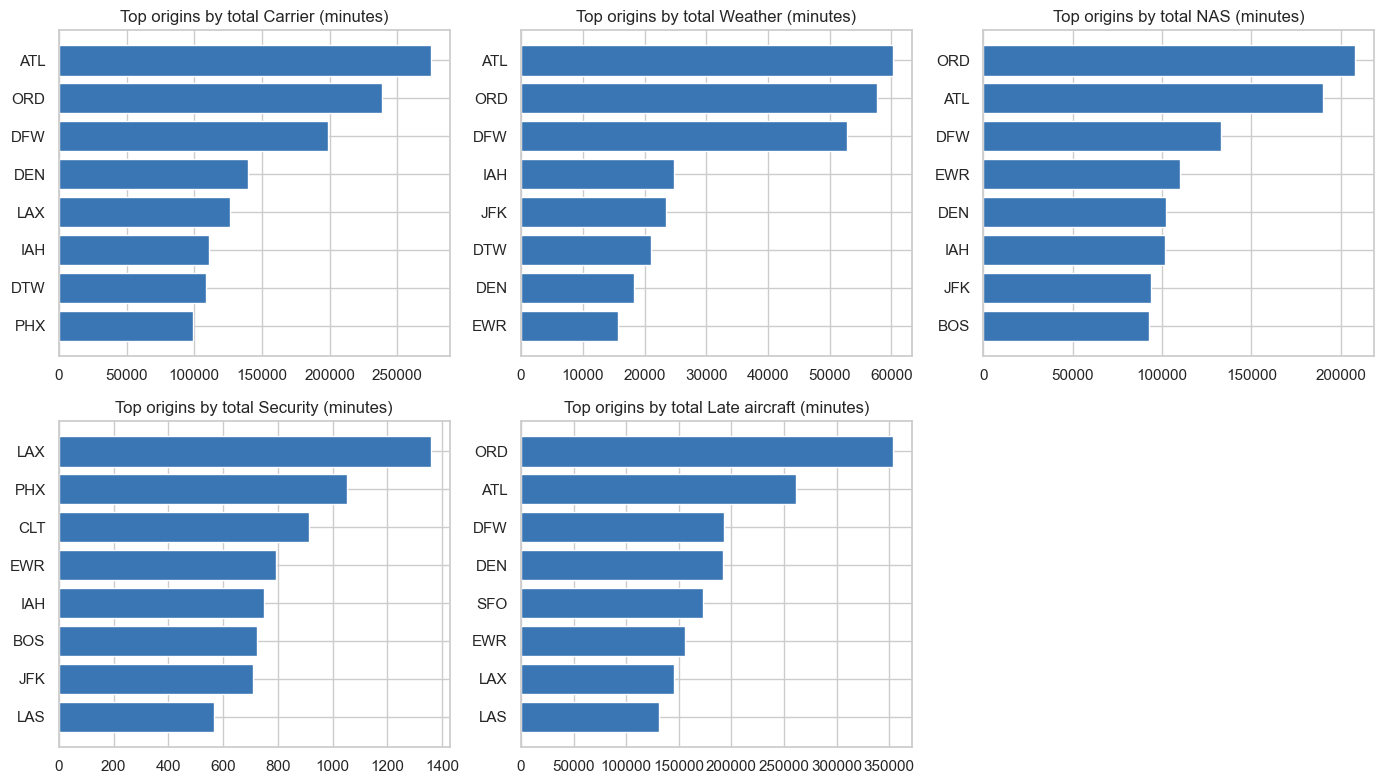

In [33]:
min_fl = 500
valid_origins = set(airport_delay_summary.loc[airport_delay_summary["flights"] >= min_fl, "Origin"])
by_origin_sum = oper.groupby("Origin", observed=True)[CAUSES].sum()
by_origin_sum = by_origin_sum[by_origin_sum.index.isin(valid_origins)]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, c, lab in zip(axes[:-1], CAUSES, CAUSE_LABELS):
    top = by_origin_sum[c].nlargest(8)
    ax.barh(top.index.astype(str), top.values, color="#3976B3")
    ax.invert_yaxis()
    ax.set_title(f"Top origins by total {lab} (minutes)")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

**Insight:**

The airport rankings by individual cause show that major hubs repeatedly appear among the top contributors, but the pattern differs somewhat by delay type:

- **Carrier Delay** is concentrated at major operational hubs such as **ATL, ORD, and DFW**, reflecting the complexity of managing high flight volumes.
- **NAS Delay** is especially prominent at busy airports connected to congested airspace regions, again highlighting the role of system-level traffic pressure.
- **Late Aircraft Delay** is strongly concentrated at large hubs, indicating that these airports are critical points for **delay propagation** across the network.
- **Weather Delay** is more unevenly distributed, suggesting that environmental conditions have a more location-specific effect.
- **Security Delay** remains very small in absolute terms, even at the airports where it is relatively highest.

Taken together, these plots reinforce the idea that **major hubs act as key nodes in the spread of delays**, and that interventions at these airports could produce network-wide improvements.

---

## G) Export of Summary Tables

The final step exports the key summary tables generated in this notebook to CSV format. These files provide reusable outputs for downstream analysis, reporting, and inclusion in the final project deliverables.

The exported summaries include:
- Overall delay-cause attribution  
- Airline-level delay summary  
- Airport-level delay summary  
- Monthly and seasonal delay summary

In [14]:
delay_cause_summary = overall.reset_index().rename(columns={"index": "cause"})
delay_cause_summary["cause"] = delay_cause_summary["cause"].map(dict(zip(CAUSES, CAUSE_LABELS)))

delay_cause_summary.to_csv("delay_cause_summary.csv", index=False)
airline_delay_summary.to_csv("airline_delay_summary.csv", index=False)
airport_delay_summary.to_csv("airport_delay_summary.csv", index=False)
seasonal_delay_summary.to_csv("seasonal_delay_summary.csv", index=False)